# 4th experiment: Multiclass classification with key bands

Selection of a subset of spectral bands based on the eigenvector information of the principal components and the feature importance parameter of the Random Forest model. The model performance is analyzed for different numbers of selected bands (5, 10, 20, 30, 40, and 60).

## Import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [2]:
def load_data():
    data = loadmat('dataset.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (43507, 121)
Train y: (43507,)
Test X: (10809, 121)
Test y: (10809,)


In [3]:
class_names = {
    12: "Sustrato Algodón-lino",
    62: "Esmalte-GA",
    63: "Lapislázuli-GA",
    64: "BlancoPb-GA",
    65: "Calcita-GA",
    85: "Esmalte-CH",
    87: "BlancoPb-CH",
    88: "Calcita-CH",
    109: "Imperial Yellow Ink-GA",
    117: "Azafrán-GA",
}

## The subset are manually defined

In [4]:
bandas_60 = np.array([
    61, 59, 49, 11, 60, 34, 8, 7, 18, 48,
    5, 9, 10, 35, 12, 33, 62, 16, 22, 2,
    20, 50, 66, 14, 19, 17, 13, 30, 29, 47,
    67, 38, 58, 24, 3, 23, 0, 1, 6, 65,
    15, 70, 36, 68, 28, 4, 40, 69, 53, 54,
    55, 21, 32, 51, 44, 56, 64, 37, 27, 31
])

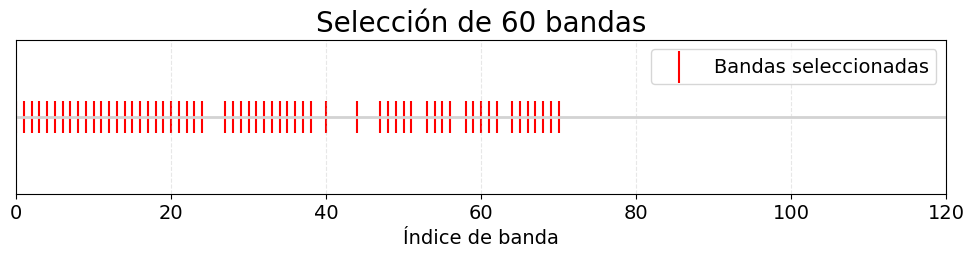

In [5]:
plt.figure(figsize=(12, 2))

plt.hlines(0, xmin=0, xmax=X_train.shape[1]-1, color='lightgray', linewidth=2)

plt.scatter(bandas_60, np.zeros_like(bandas_60),
            color='red', marker='|', s=500, label="Bandas seleccionadas")

plt.xlabel("Índice de banda",fontsize=14)
plt.yticks([])
plt.xticks(fontsize=14)
plt.title("Selección de 60 bandas",fontsize=20)

plt.xlim(0, X_train.shape[1] - 1)
plt.grid(True, axis="x", linestyle="--", alpha=0.3)
plt.legend(fontsize=14)

plt.show()

In [6]:
bandas_5=np.array([60,49,8,34,18])
bandas_10=np.array([60,67,55,49,8,35,30,2,18,44])
bandas_20=np.array([60,62,65,58,67,70,55,49,44,40,35,33,30,27,8,2,18,21,12,24])
bandas_30 = np.array([60,62,65,58,67,70,55,49,44,40,35,33,30,27,8,2,18,21,12,24,0, 6, 10, 16, 23, 29, 38, 47, 53, 66])
bandas_40 = np.array([60,62,65,58,67,70,55,49,44,40,35,33,30,27,8,2,18,21,12,24, 6, 10, 16, 23, 29, 38, 47, 53, 69,1, 5, 9, 14, 19, 31, 36, 50, 56, 64,59])

In [7]:
colores = {
    "60 bandas": "red",
    "40 bandas": "orange",
    "30 bandas": "green",
    "20 bandas": "blue",
    "10 bandas": "purple",
    "5 bandas": "black",
}

conjuntos_bandas = {
    "60 bandas": bandas_60,
    "40 bandas": bandas_40,
    "30 bandas": bandas_30,
    "20 bandas": bandas_20,
    "10 bandas": bandas_10,
    "5 bandas": bandas_5,
}

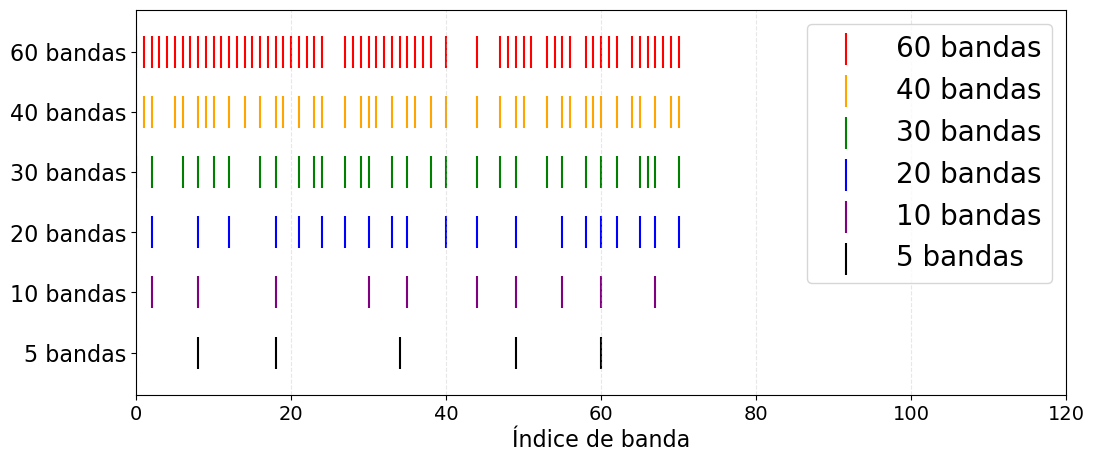

In [8]:
plt.figure(figsize=(12, 5))

y_pos = np.arange(len(conjuntos_bandas))[::-1]

for i, (nombre, bandas) in enumerate(conjuntos_bandas.items()):
    y = y_pos[i]

    plt.scatter(
        bandas,
        np.full_like(bandas, y),
        marker="|",
        s=500,
        color=colores[nombre],
        label=nombre
    )

plt.yticks(y_pos, conjuntos_bandas.keys(),fontsize=16)
plt.xlabel("Índice de banda",fontsize=16)
plt.xlim(0,120)
plt.ylim(-0.7, len(conjuntos_bandas)-0.3)
plt.xticks(fontsize=14)

plt.grid(True, axis="x", linestyle="--", alpha=0.3)
plt.legend(loc="upper right",fontsize=20)

plt.show()

## Study of performance evaluation in classification

In [9]:
resultados = [] 

In [10]:
Xtr_full = X_train
Xte_full = X_test

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

model.fit(Xtr_full, y_train)
y_pred = model.predict(Xte_full)

In [11]:
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="weighted")

resultados.append((121, acc, f1))

print(f"121 bandas: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

121 bandas: Accuracy = 0.7410, F1 = 0.7559


In [12]:
for nombre, bandas in conjuntos_bandas.items():                     #recorremos cada conjunto de bandas
    
    Xtr = X_train[:, bandas]                                        #Usamos los conjuntos de datos correspondientes a las bandas seleccionadas
    Xte = X_test[:, bandas]
    
    model = Pipeline([                                              #modelo SVM
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
    ])
    
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")
    
    resultados.append((len(bandas), acc, f1))                           # guardamos resultados en la lista
    
    print(f"{nombre}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

60 bandas: Accuracy = 0.7857, F1 = 0.7969
40 bandas: Accuracy = 0.7886, F1 = 0.7998
30 bandas: Accuracy = 0.7890, F1 = 0.7988
20 bandas: Accuracy = 0.7843, F1 = 0.7937
10 bandas: Accuracy = 0.7806, F1 = 0.7920
5 bandas: Accuracy = 0.7735, F1 = 0.7877


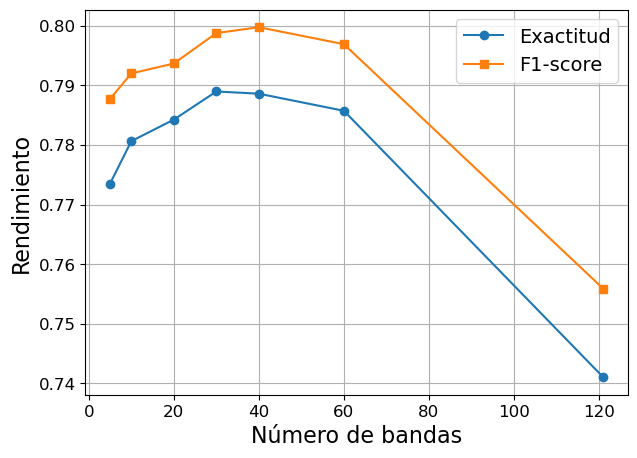

In [14]:
resultados_ordenados = sorted(resultados, key=lambda x: x[0])

n_bandas = [r[0] for r in resultados_ordenados]
accs     = [r[1] for r in resultados_ordenados]
f1s      = [r[2] for r in resultados_ordenados]

plt.figure(figsize=(7,5))

plt.plot(n_bandas, accs, marker="o", label="Exactitud")
plt.plot(n_bandas, f1s, marker="s", label="F1-score")

plt.xlabel("Número de bandas",fontsize=16)
plt.ylabel("Rendimiento",fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)
plt.legend(fontsize=14)
plt.show()

## If a binarization is done first

In [15]:
def load_data():
    data = loadmat('dataset_without_substrate.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (39507, 121)
Train y: (39507,)
Test X: (9809, 121)
Test y: (9809,)


In [16]:
resultados = [] 

In [17]:
Xtr_full = X_train
Xte_full = X_test

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

model.fit(Xtr_full, y_train)
y_pred = model.predict(Xte_full)

In [18]:
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="weighted")

resultados.append((121, acc, f1))

print(f"121 bandas: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

121 bandas: Accuracy = 0.7924, F1 = 0.7956


In [19]:
for nombre, bandas in conjuntos_bandas.items():                     #recorremos cada conjunto de bandas
    
    Xtr = X_train[:, bandas]                                        #Usamos los conjuntos de datos correspondientes a las bandas seleccionadas
    Xte = X_test[:, bandas]
    
    model = Pipeline([                                              #modelo SVM
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
    ])
    
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")
    
    resultados.append((len(bandas), acc, f1))                           # guardamos resultados en la lista
    
    print(f"{nombre}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

60 bandas: Accuracy = 0.8428, F1 = 0.8432
40 bandas: Accuracy = 0.8442, F1 = 0.8447
30 bandas: Accuracy = 0.8375, F1 = 0.8380
20 bandas: Accuracy = 0.8332, F1 = 0.8330
10 bandas: Accuracy = 0.8323, F1 = 0.8336
5 bandas: Accuracy = 0.8328, F1 = 0.8399


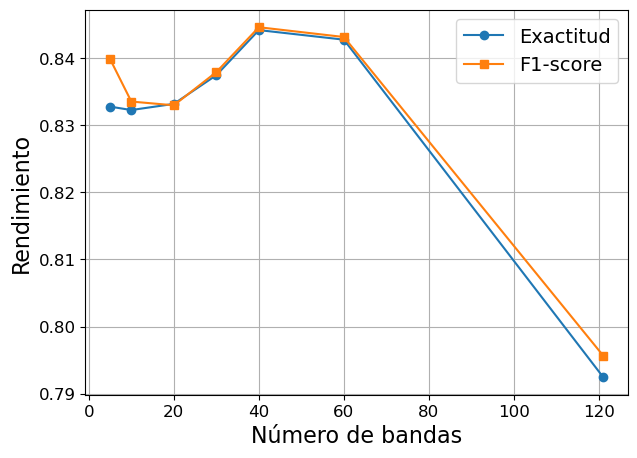

In [20]:
resultados_ordenados = sorted(resultados, key=lambda x: x[0])

n_bandas = [r[0] for r in resultados_ordenados]
accs     = [r[1] for r in resultados_ordenados]
f1s      = [r[2] for r in resultados_ordenados]

plt.figure(figsize=(7,5))

plt.plot(n_bandas, accs, marker="o", label="Exactitud")
plt.plot(n_bandas, f1s, marker="s", label="F1-score")

plt.xlabel("Número de bandas",fontsize=16)
plt.ylabel("Rendimiento",fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)
plt.legend(fontsize=14)
plt.show()

In [21]:
df_resultados = pd.DataFrame(
    resultados_ordenados,
    columns=["n_bandas", "accuracy", "f1_score"]
)

df_resultados

,n_bandas,accuracy,f1_score
0,5,0.832807,0.839907
1,10,0.832297,0.833565
2,20,0.833214,0.833004
3,30,0.837496,0.837963
4,40,0.844225,0.844653
5,60,0.842797,0.843193
6,121,0.792436,0.795641
